In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("student-mat.csv", sep=";")

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [7]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


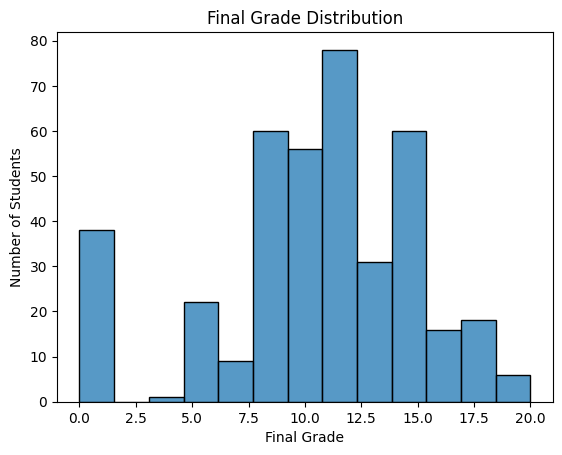

In [8]:
sns.histplot(df['G3'])
plt.title("Final Grade Distribution")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

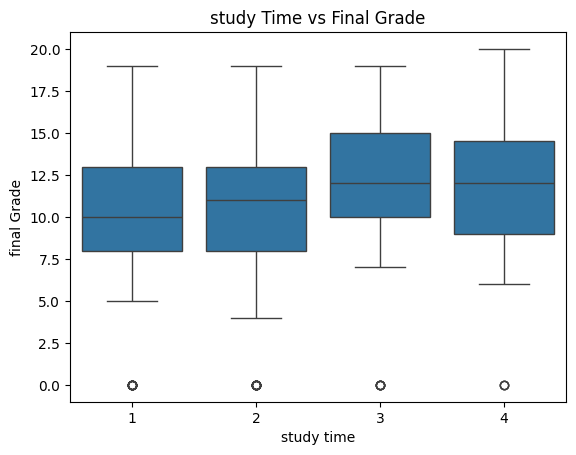

In [11]:
sns.boxplot(x='studytime', y= 'G3', data=df)
plt.title("study Time vs Final Grade")
plt.xlabel("study time")
plt.ylabel("final Grade")
plt.show()

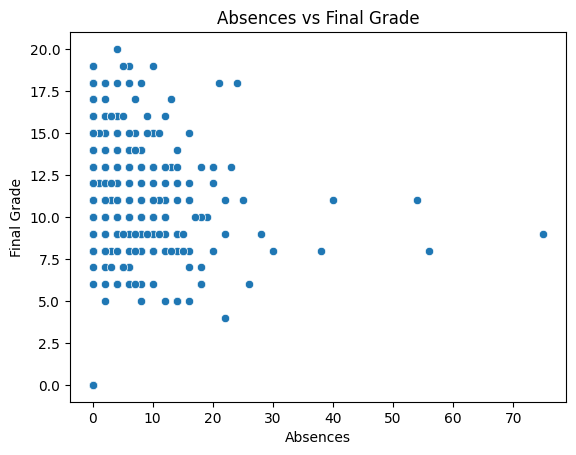

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student-mat.csv", sep=";")

sns.scatterplot(x='absences', y='G3', data=df)
    
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
    
plt.show()

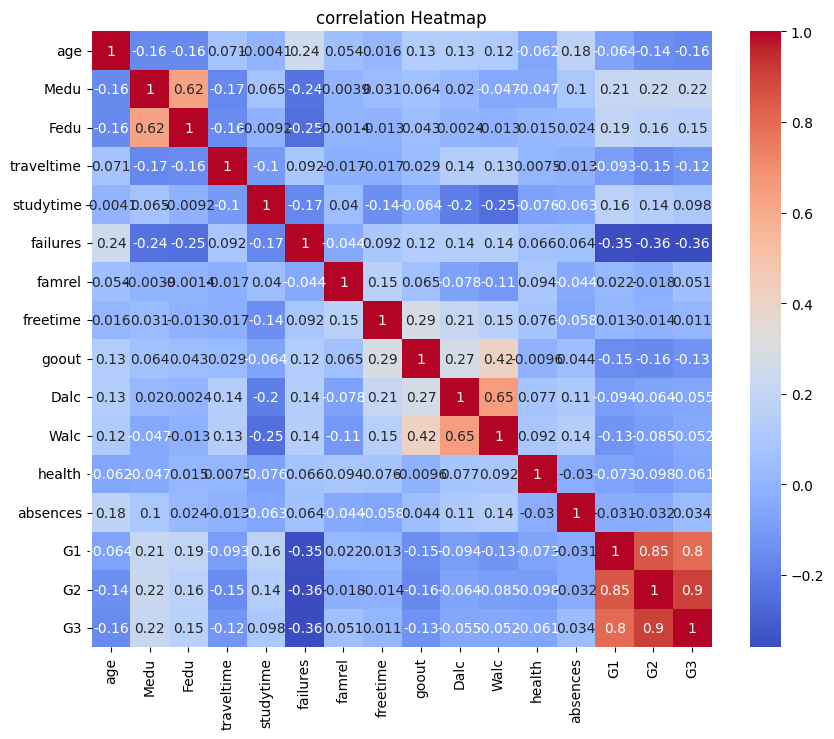

In [12]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("correlation Heatmap")
plt.show()

In [13]:
correlation = df.corr(numeric_only=True)
print(correlation['G3'].sort_values(ascending=False))

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df[['studytime', 'failures', 'absences']]
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 3.5605831369551635


In [15]:
results = pd.DataFrame({
    'Actual Grade': y_test,
    'Predicted Grade': predictions
})

print(results.head(10))

     Actual Grade  Predicted Grade
78             10         3.583927
371            12        10.429238
248             5         8.880879
55             10        11.148884
390             9         6.736754
223            13        10.818534
42             18        10.901121
234             6        11.561823
316             0        10.818534
116            14        10.901121


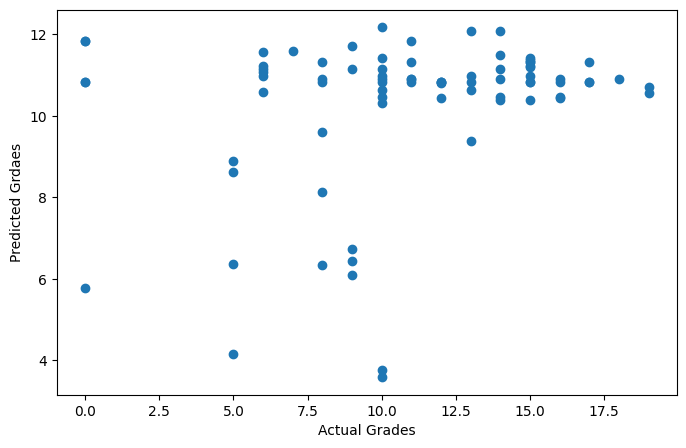

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grdaes")

plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df[['studytime', 'failures', 'absences',
        'G1', 'G2', 'Medu', 'Fedu']]

y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 1.3361056406680167


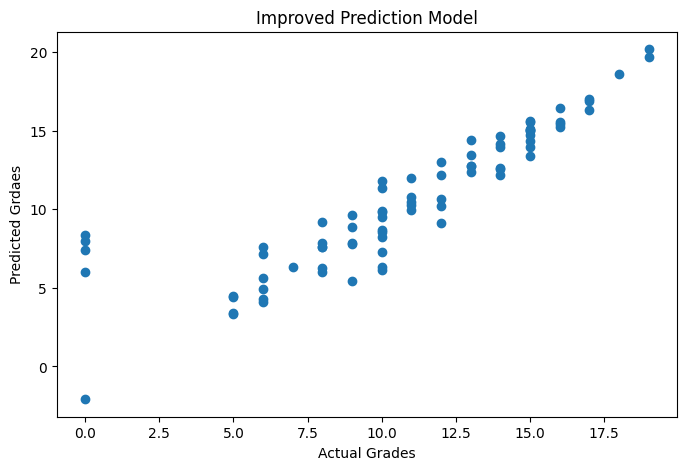

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grdaes")

plt.title("Improved Prediction Model")

plt.show()

In [21]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("R2 Score:", score)

R2 Score: 0.7806212503957508


In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,G2,0.974347
3,G1,0.151102
5,Medu,0.112130
2,absences,0.038177
0,studytime,-0.089307
6,Fedu,-0.174771
1,failures,-0.483860


# Student Performance Analysis

## Objective
Analyze factors affecting student grades and build a machine learning model to predict final grades.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## Key Findings
- Previous grades (G1 and G2) strongly predict final grades.
- More failures reduce performance.
- Parent education has some influence.

## Model Performance
The linear regression model achieved an R² score of 0.78.